<a href="https://colab.research.google.com/github/alhorvath2000/Thesis-Excel/blob/main/12467_Session3_Class26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 12467 - Advanced Topics in Empirical Finance
## Class 3: Issues with the sample covariance and shrinkage

### A wider list of tickers

In [ ]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/S%26P_100"

headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(url, headers=headers)
response.raise_for_status()

tables = pd.read_html(response.text)

/tmp/ipykernel_22336/1766779587.py:10: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [ ]:
tickers = tables[2]["Symbol"].to_list()
tickers

['AAPL',
 'ABBV',
 'ABT',
 'ACN',
 'ADBE',
 'AMAT',
 'AMD',
 'AMGN',
 'AMT',
 'AMZN',
 'AVGO',
 'AXP',
 'BA',
 'BAC',
 'BK',
 'BKNG',
 'BLK',
 'BMY',
 'BRK.B',
 'C',
 'CAT',
 'CL',
 'CMCSA',
 'COF',
 'COP',
 'COST',
 'CRM',
 'CSCO',
 'CVS',
 'CVX',
 'DE',
 'DHR',
 'DIS',
 'DUK',
 'EMR',
 'FDX',
 'GD',
 'GE',
 'GEV',
 'GILD',
 'GM',
 'GOOG',
 'GOOGL',
 'GS',
 'HD',
 'HON',
 'IBM',
 'INTC',
 'INTU',
 'ISRG',
 'JNJ',
 'JPM',
 'KO',
 'LIN',
 'LLY',
 'LMT',
 'LOW',
 'LRCX',
 'MA',
 'MCD',
 'MDLZ',
 'MDT',
 'META',
 'MMM',
 'MO',
 'MRK',
 'MS',
 'MSFT',
 'MU',
 'NEE',
 'NFLX',
 'NKE',
 'NOW',
 'NVDA',
 'ORCL',
 'PEP',
 'PFE',
 'PG',
 'PLTR',
 'PM',
 'QCOM',
 'RTX',
 'SBUX',
 'SCHW',
 'SO',
 'SPG',
 'T',
 'TMO',
 'TMUS',
 'TSLA',
 'TXN',
 'UBER',
 'UNH',
 'UNP',
 'UPS',
 'USB',
 'V',
 'VZ',
 'WFC',
 'WMT',
 'XOM']

### Code from last session
Below are the relevant code snippets from the previous session, covering data download, sample splitting, and the computation of out-of-sample performance for the portfolios of interest, along with the auxiliary functions used to carry out these tasks.

In [ ]:
import yfinance as yf
from datetime import datetime
import numpy as np

In [ ]:
myStart = datetime(2020,1,1)
breakDate = datetime(2025,1,1)
myEnd = datetime(2025,12,31)

prices = pd.DataFrame()

for tick in tickers:
  data = yf.download(tick, start = myStart, end = myEnd, auto_adjust = True)
  prices[tick] = data['Close']

data = yf.download("^IRX", start = myStart, end = myEnd)
rf_series = data["Close"]/100

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

In [ ]:
prices = prices.dropna(axis=1)
prices.shape

(1507, 98)

In [ ]:
def getMoments(prices_fct):
  returns_fct = (prices_fct/prices_fct.shift(1))[1:]-1
  mu_fct = returns_fct.mean()*250
  cov_fct = returns_fct.cov()*250
  return mu_fct, cov_fct

mutest, covtest = getMoments(prices)

In [ ]:
def ptf_stats(weights_fct, mu_fct, cov_fct, rf_fct):
  ptf_mu_fct = weights_fct @ mu_fct
  ptf_var_fct = weights_fct @ cov_fct @ weights_fct
  ptf_std_fct = np.sqrt(ptf_var_fct)
  ptf_SR_fct = (ptf_mu_fct-rf_fct)/ptf_std_fct
  return ptf_mu_fct, ptf_var_fct, ptf_SR_fct

In [ ]:
def optPortNum(cov, mu = None, flag = 1):

  # flag = 1 --> minimum variance portfolio (that requires only cov)
  # flag = 2 --> maximum Sharpe ratio portfolio (that requires also mu)

  N = cov.shape[0]

  if flag == 1:
    a = np.ones(shape = N)
  elif flag == 2:
    a = mu

  wstar = (np.linalg.inv(cov) @ a) / (a @ np.linalg.inv(cov) @ a)

  return wstar/wstar.sum()

In [ ]:
prices_training = prices[myStart:breakDate]
prices_test = prices[breakDate:myEnd]
rf_series_training = rf_series[myStart:breakDate]
rf_series_test = rf_series[breakDate:myEnd]

In [ ]:
mu_training, cov_training = getMoments(prices_training)
mu_test, cov_test = getMoments(prices_test)
rf_test = rf_series_test.mean().iloc[0]

In [ ]:
w_MV_training = optPortNum(cov_training)
w_MSR_training = optPortNum(cov_training, mu_training, flag = 2)

In [ ]:
N = cov_training.shape[0]
EWP = np.ones(shape = N)/N

w_EWP_statsOOS = ptf_stats(EWP, mu_test, cov_test, rf_test)
w_MV_statsOOS = ptf_stats(w_MV_training, mu_test, cov_test, rf_test)
w_MSR_statsOOS = ptf_stats(w_MSR_training, mu_test, cov_test, rf_test)

<Axes: >

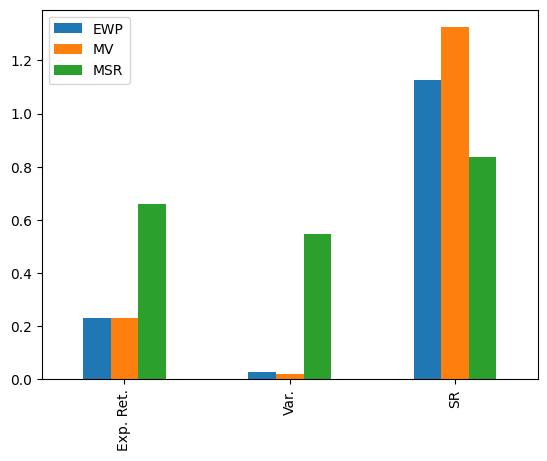

In [ ]:
statsOOS = pd.DataFrame( [w_EWP_statsOOS, w_MV_statsOOS, w_MSR_statsOOS], columns = ['Exp. Ret.', 'Var.', 'SR'], \
                          index = ['EWP', 'MV', 'MSR'])

(statsOOS.T).plot(kind = 'bar')

In [ ]:
statsOOS

,Exp. Ret.,Var.,SR
EWP,0.229967,0.028218,1.127723
MV,0.231452,0.020765,1.324929
MSR,0.659276,0.545528,0.837730


### Precision of the returns' sample variance
This section investigates the reliability of the sample variance (under the assumption of zero expected log return) as an estimator of log returns population variance. Using historical price data for a single asset, the code computes log-returns at both annual and daily frequencies, and then derives their sample variances, standard deviations, and standard errors. By constructing confidence intervals and t.ratios, the analysis highlights how the quality of the estimate of (log) returns variance DOES improve increasing data frequency.

In [ ]:
pricesBAC = yf.download("BAC", datetime(2014, 12 ,31), datetime(2024, 12 ,31), auto_adjust = True)
pricesBAC = pricesBAC["Close"]
pricesBAC

[*********************100%***********************]  1 of 1 completed


Ticker,BAC
Date,
2014-12-31,14.115913
2015-01-02,14.123799
2015-01-05,13.713498
2015-01-06,13.303197
2015-01-07,13.366324
...,...
2024-12-23,42.655346
2024-12-24,43.131565
2024-12-26,43.296780


In [ ]:
pricesBAC_Y = pricesBAC.resample("YE").last()
pricesBAC_Y

Ticker,BAC
Date,
2014-12-31,14.115913
2015-12-31,13.441761
2016-12-31,17.927065
2017-12-31,24.324371
2018-12-31,20.676556
2019-12-31,30.227108
2020-12-31,26.710798
2021-12-31,39.961758
2022-12-31,30.441690


In [ ]:
r_Y = np.log(pricesBAC_Y/pricesBAC_Y.shift(1))
r_Y = r_Y.dropna()

In [ ]:
r_Y

Ticker,BAC
Date,
2015-12-31,-0.048936
2016-12-31,0.287945
2017-12-31,0.305167
2018-12-31,-0.162478
2019-12-31,0.379739
2020-12-31,-0.123671
2021-12-31,0.402855
2022-12-31,-0.272110
2023-12-31,0.047131


In [ ]:
r_Y.describe()

Ticker,BAC
count,10.000000
mean,0.110631
std,0.250551
min,-0.272110
25%,-0.104988
50%,0.167538
75%,0.301541
max,0.402855


In [ ]:
var_Y = r_Y.var().iloc[0]
var_Y

np.float64(0.06277568675902474)

In [ ]:
std_Y = np.sqrt(var_Y)
std_Y

np.float64(0.2505507668298478)

In [ ]:
n_Y = len(r_Y)
n_Y

10

In [ ]:
ste_var_Y = np.sqrt(2/n_Y)*var_Y
ste_var_Y

np.float64(0.028074140585482556)

In [ ]:
lb_Y = var_Y -2*ste_var_Y
ub_Y = var_Y +2*ste_var_Y

In [ ]:
print(f"Annual log return sample variance = {var_Y:.6f}, 95% CI: [{lb_Y:.6f}, {ub_Y:.6f}]")

Annual log return sample variance = 0.062776, 95% CI: [0.006627, 0.118924]


In [ ]:
print(f"Annual log return sample std. dev. = {np.sqrt(var_Y):.6f}, 95% CI: [{np.sqrt(lb_Y):.6f}, {np.sqrt(ub_Y):.6f}]")

Annual log return sample std. dev. = 0.250551, 95% CI: [0.081409, 0.344854]


In [ ]:
tratio_Y = var_Y/ste_var_Y
tratio_Y

np.float64(2.23606797749979)

In [ ]:
r = np.log(pricesBAC/pricesBAC.shift(1))
r = r.dropna()

In [ ]:
var_D = r.var().to_numpy()[0]
var_D

np.float64(0.0003831832565121394)

In [ ]:
std_D = r.std().to_numpy()[0]
std_D

np.float64(0.019575067216031198)

In [ ]:
n_D = len(r)
n_D

2515

In [ ]:
ste_var_D = np.sqrt(2*var_D**2/n_D)
ste_var_D

np.float64(1.0805690573230938e-05)

In [ ]:
lb_D = var_D-2*ste_var_D
lb_D

np.float64(0.0003615718753656775)

In [ ]:
ub_D = var_D+2*ste_var_D
ub_D

np.float64(0.00040479463765860126)

In [ ]:
print(f"Daily log return sample mean = {var_D:.6f}, 95% CI: [{lb_D:.6f}, {ub_D:.6f}]")

Daily log return sample mean = 0.000383, 95% CI: [0.000362, 0.000405]


In [ ]:
print(f"Daily log return sample std. dev. = {np.sqrt(var_D):.6f}, 95% CI: [{np.sqrt(lb_D):.6f}, {np.sqrt(ub_D):.6f}]")

Daily log return sample std. dev. = 0.019575, 95% CI: [0.019015, 0.020120]


In [ ]:
annFct = n_D/n_Y
annFct

251.5

In [ ]:
annualized_var = var_D*annFct
annualized_var

np.float64(0.09637058901280306)

In [ ]:
var_Y

np.float64(0.06277568675902474)

In [ ]:
print(f"{'Method':<35} {'Var':>12} {'95% CI Lower':>15} {'95% CI Upper':>15}")
print("-" * 80)
print(f"{'Annual (from yearly data)':<35} {var_Y:12.6f} {lb_Y:15.6f} {ub_Y:15.6f}")
print(f"{'Annualized (from daily data)':<35} {var_D*annFct:12.6f} {lb_D*annFct:15.6f} {ub_D*annFct:15.6f}")

Method                                       Var    95% CI Lower    95% CI Upper
--------------------------------------------------------------------------------
Annual (from yearly data)               0.062776        0.006627        0.118924
Annualized (from daily data)            0.096371        0.090935        0.101806


In [ ]:
print(f"{'Method':<35} {'Std. Dev.':>12} {'95% CI Lower':>15} {'95% CI Upper':>15}")
print("-" * 80)
print(f"{'Annual (from yearly data)':<35} {np.sqrt(var_Y):12.6f} {np.sqrt(lb_Y):15.6f} {np.sqrt(ub_Y):15.6f}")
print(f"{'Annualized (from daily data)':<35} {np.sqrt(var_D*annFct):12.6f} {np.sqrt(lb_D*annFct):15.6f} {np.sqrt(ub_D*annFct):15.6f}")

Method                                 Std. Dev.    95% CI Lower    95% CI Upper
--------------------------------------------------------------------------------
Annual (from yearly data)               0.250551        0.081409        0.344854
Annualized (from daily data)            0.310436        0.301555        0.319070


In [ ]:
tratio_D = var_D/ste_var_D
tratio_D

np.float64(35.46124645299429)

### Analysis of the sample variance-covariance and correlation matrices and shrinkage
In what follows, we analyze the sample variance-covariance matrix and the sample correlation matrix for a large cross-section of returns. The aim is to show that pairwise correlations do not differ substantially from one another, allowing us to reduce the number of parameters to be estimated in the covariance matrix by assuming a constant correlation structure, i.e., by applying shrinkage.

In [ ]:
cov_training

,AAPL,ABBV,ABT,ACN,ADBE,AMAT,AMD,AMGN,AMT,AMZN,...,UBER,UNH,UNP,UPS,USB,V,VZ,WFC,WMT,XOM
AAPL,0.099557,0.023092,0.038550,0.054653,0.075726,0.087061,0.092606,0.032573,0.043188,0.066933,...,0.061087,0.039310,0.038764,0.043088,0.041809,0.051205,0.018385,0.044445,0.025772,0.030453
ABBV,0.023092,0.060944,0.028726,0.025943,0.024850,0.032481,0.019469,0.030858,0.027174,0.013684,...,0.024756,0.034981,0.024842,0.021903,0.032489,0.028258,0.017177,0.031192,0.015307,0.027178
ABT,0.038550,0.028726,0.067811,0.039944,0.043160,0.043851,0.044664,0.031135,0.042927,0.031567,...,0.031540,0.036682,0.030602,0.033172,0.034876,0.037100,0.020977,0.034197,0.020187,0.019517
ACN,0.054653,0.025943,0.039944,0.085932,0.066827,0.075227,0.071204,0.029475,0.045266,0.051288,...,0.063531,0.038503,0.044774,0.041421,0.056315,0.052583,0.021313,0.055612,0.021054,0.035196
ADBE,0.075726,0.024850,0.043160,0.066827,0.149944,0.102441,0.112490,0.033000,0.048989,0.084186,...,0.082298,0.037783,0.038572,0.045315,0.041135,0.056678,0.013980,0.042407,0.026409,0.022684
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
V,0.051205,0.028258,0.037100,0.052583,0.056678,0.067167,0.061543,0.028116,0.039850,0.040383,...,0.063202,0.041053,0.044277,0.036774,0.057450,0.077139,0.020541,0.058860,0.018067,0.043145
VZ,0.018385,0.017177,0.020977,0.021313,0.013980,0.015476,0.013511,0.019501,0.028985,0.012436,...,0.010943,0.022493,0.020410,0.019597,0.032797,0.020541,0.045504,0.029086,0.014920,0.023157
WFC,0.044445,0.031192,0.034197,0.055612,0.042407,0.077113,0.056924,0.031789,0.039239,0.034679,...,0.069806,0.046098,0.058946,0.047017,0.118582,0.058860,0.029086,0.151832,0.019960,0.073041
WMT,0.025772,0.015307,0.020187,0.021054,0.026409,0.026557,0.026678,0.020852,0.023348,0.023901,...,0.008284,0.020150,0.015512,0.022079,0.017258,0.018067,0.014920,0.019960,0.050554,0.013641


In [ ]:
np.linalg.det(cov_training)

np.float64(4.374204370672639e-139)

In [ ]:
np.linalg.matrix_rank(cov_training)

np.int64(98)

In [ ]:
def cov2corr(cov_fct):
  stds_fct = np.sqrt(np.diag(cov_fct))
  return cov_fct/np.outer(stds_fct, stds_fct)

In [ ]:
corr_training = cov2corr(cov_training)
corr_training

,AAPL,ABBV,ABT,ACN,ADBE,AMAT,AMD,AMGN,AMT,AMZN,...,UBER,UNH,UNP,UPS,USB,V,VZ,WFC,WMT,XOM
AAPL,1.000000,0.296458,0.469181,0.590884,0.619790,0.592859,0.561703,0.395626,0.449119,0.592200,...,0.356717,0.418541,0.447419,0.453504,0.350181,0.584309,0.273157,0.361497,0.363277,0.281849
ABBV,0.296458,1.000000,0.446853,0.358497,0.259960,0.282699,0.150934,0.479034,0.361176,0.154744,...,0.184765,0.476035,0.366470,0.294644,0.347798,0.412142,0.326185,0.324260,0.275778,0.321496
ABT,0.469181,0.446853,1.000000,0.523262,0.428024,0.361827,0.328258,0.458216,0.540892,0.338413,...,0.223164,0.473230,0.427969,0.423047,0.353942,0.512960,0.377624,0.337024,0.344786,0.218869
ACN,0.590884,0.358497,0.523262,1.000000,0.588723,0.551393,0.464871,0.385339,0.506674,0.488430,...,0.399321,0.441247,0.556248,0.469247,0.507696,0.645847,0.340834,0.486865,0.319428,0.350628
ADBE,0.619790,0.259960,0.428024,0.588723,1.000000,0.568428,0.555971,0.326602,0.415112,0.606927,...,0.391596,0.327792,0.362759,0.388626,0.280739,0.527000,0.169249,0.281052,0.303326,0.171075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
V,0.584309,0.412142,0.512960,0.645847,0.527000,0.519623,0.424082,0.387958,0.470788,0.405909,...,0.419284,0.496560,0.580570,0.439709,0.546658,1.000000,0.346705,0.543880,0.289313,0.453655
VZ,0.273157,0.326185,0.377624,0.340834,0.169249,0.155881,0.121218,0.350352,0.445835,0.162747,...,0.094523,0.354238,0.348452,0.305081,0.406322,0.346705,1.000000,0.349927,0.311072,0.317023
WFC,0.361497,0.324260,0.337024,0.486865,0.281052,0.425220,0.279589,0.312654,0.330425,0.248458,...,0.330083,0.397435,0.550918,0.400714,0.804261,0.543880,0.349927,1.000000,0.227828,0.547411
WMT,0.363277,0.275778,0.344786,0.319428,0.303326,0.253782,0.227080,0.355407,0.340722,0.296760,...,0.067888,0.301065,0.251245,0.326104,0.202849,0.289313,0.311072,0.227828,1.000000,0.177168


In [ ]:
np.min(corr_training)

0.041352908270343054

In [ ]:
np.max(corr_training[ corr_training < 0.99 ])

0.9289405979334306

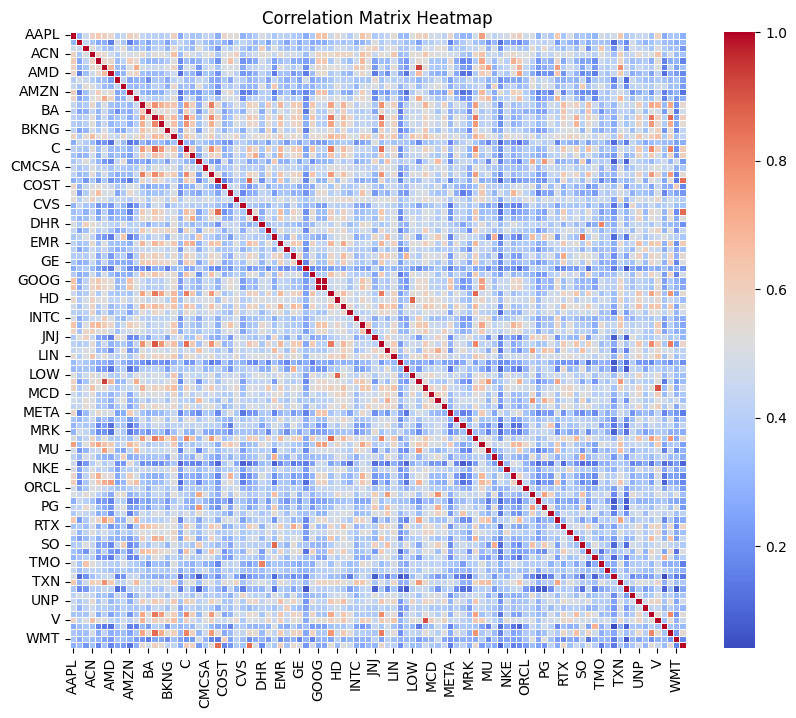

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_training,
            cmap='coolwarm',
            linewidths=0.5,
            square=True)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
w_MV_shrinkage_training = optPortNum(cov_training_shrunk)
w_MV_shrinkage_statsOSS = ptf_stats(w_MV_shrinkage_training, mu_test, cov_test, rf_test)

In [ ]:
stats_OOS = pd.DataFrame([w_EWP_statsOOS, w_MV_statsOOS, w_MV_shrinkage_statsOSS], \
  columns = ['Exp Return', 'Var', 'SR'], \
  index = ['EWP','MV','MV + Shrinkage'])

stats_OOS

In [ ]:
(stats_OOS.T).plot(kind='bar');